
# Flight Fare Prediction Using Machine Learning

**Abstract:**
This project presents a complete end-to-end machine learning workflow for predicting airline ticket prices. The study includes comprehensive data preprocessing (missing value handling, outlier treatment, and categorical encoding), exploratory data analysis (EDA), feature engineering (time-based and duration features), and model development using multiple regression algorithms. Several models—including Linear Regression, Decision Trees, Random Forest, Gradient Boosting, and XGBoost—were trained and evaluated using log-transformed target values to address skewness.

After extensive comparison and hyperparameter tuning via RandomizedSearchCV, XGBoost emerged as the best-performing model based on R², RMSE, and MAE on actual price values. SHAP explainability techniques were further applied to interpret feature contributions and ensure model transparency. The final model was saved using a full preprocessing pipeline to support deployment. This notebook demonstrates a robust machine learning methodology for real-world flight fare prediction.

In [58]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

 **Explanation:** This step imports all the essential Python libraries required for the project. Pandas and NumPy are used for data manipulation and numerical operations, while Matplotlib and Seaborn support visual exploration of patterns and trends in the dataset. Warnings are temporarily suppressed to keep the notebook output clean and easy to read. Together, these libraries form the foundation for data preprocessing, visualization, and building machine-learning models later in the workflow.

In [2]:
#Loading the data
data = pd.read_excel('Flight_Fare.xlsx')

**Explanation**: The dataset is imported from an Excel file into a pandas DataFrame.
This allows us to inspect, clean, and manipulate the dataset efficiently.

In [3]:
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [4]:
data.shape

(10683, 11)

**Explanatiom:** The data.shape command displays the size of the dataset. The output (10683, 11) indicates that the flight fare dataset contains 10,683 rows (individual flight records) and 11 columns (features describing each flight). This helps understand the dataset’s scale before performing analysis or modeling

In [5]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [6]:
data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [9]:
data.describe(include='O')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683
unique,12,44,5,6,128,222,1343,368,5,10
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info
freq,3849,504,4537,4537,2376,233,423,550,5625,8345


In [10]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

**Explanation:** Use .info(), .describe() and .isnull().sum() to examine data types, distributions and missing values. This guides the cleaning strategy.

In [11]:
data['Route'].fillna(data['Route'].mode()[0], inplace=True)
data['Total_Stops'].fillna(data['Total_Stops'].mode()[0], inplace=True)



**Explanation:** Missing values in Route and Total_Stops are filled using the mode (most frequent category). Since these are categorical features, mode imputation is appropriate and ensures the dataset remains complete without introducing bias or distorting numerical relationships

In [12]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

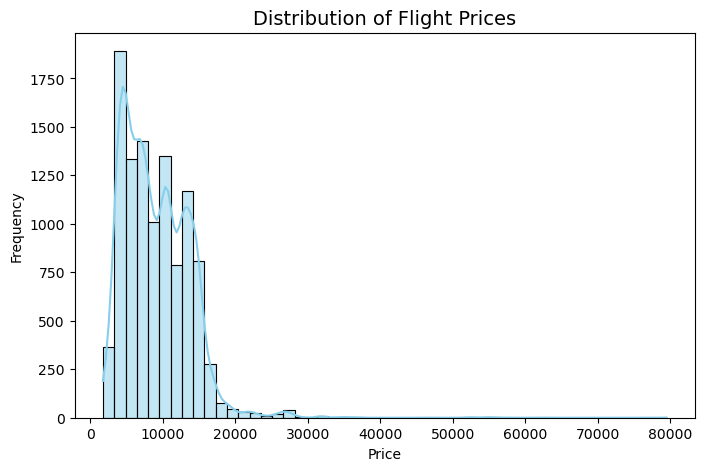

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data['Price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Flight Prices', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


**Explanation:** This histogram visualizes the distribution of flight prices. The plot shows a strong right-skew, meaning most flights are priced in the lower range while a smaller number of flights are much more expensive. The KDE curve helps reveal the density pattern, confirming that high-priced flights are rare outliers.

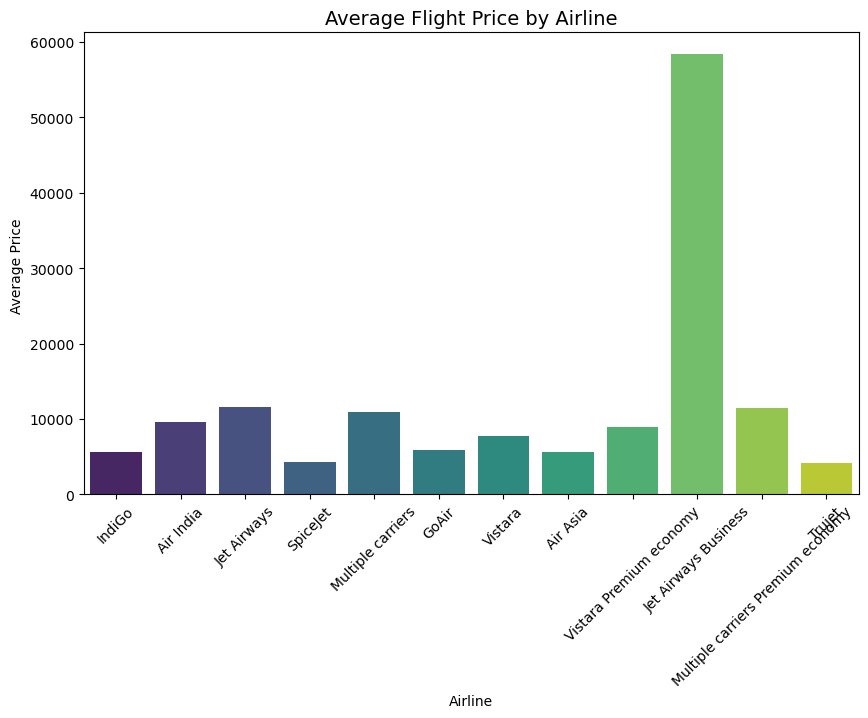

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x='Airline', y='Price', data=data, estimator='mean', ci=None, palette='viridis')
plt.title('Average Flight Price by Airline', fontsize=14)
plt.xlabel('Airline')
plt.ylabel('Average Price ')
plt.xticks(rotation=45)
plt.show()



**Explanation:** This bar chart shows the average ticket price for each airline. It helps identify which airlines typically charge higher or lower fares. Vistara Premium economy show much higher prices, while budget airlines such as IndiGo and SpiceJet offer relatively cheaper fares. This visualization highlights how airline choice significantly influences flight prices.

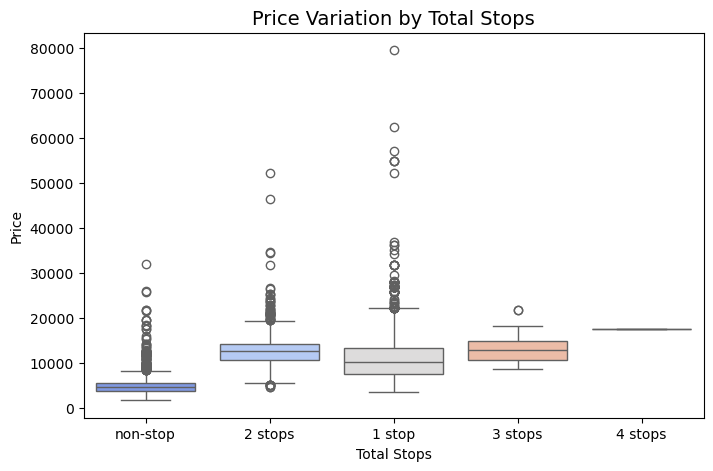

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Total_Stops', y='Price', data=data, palette='coolwarm')
plt.title('Price Variation by Total Stops', fontsize=14)
plt.xlabel('Total Stops')
plt.ylabel('Price')
plt.show()


**Explanation:** This boxplot illustrates how flight prices change based on the number of stops. Non-stop flights generally show the lowest and most stable prices, while flights with 1 or 2 stops exhibit wider variability and higher median fares. As the number of stops increases, price dispersion also grows, reflecting more diverse routing and airline options. Outliers indicate premium or unusually priced multi-stop routes. Overall, the plot highlights that more stops tend to increase both cost and price variability.

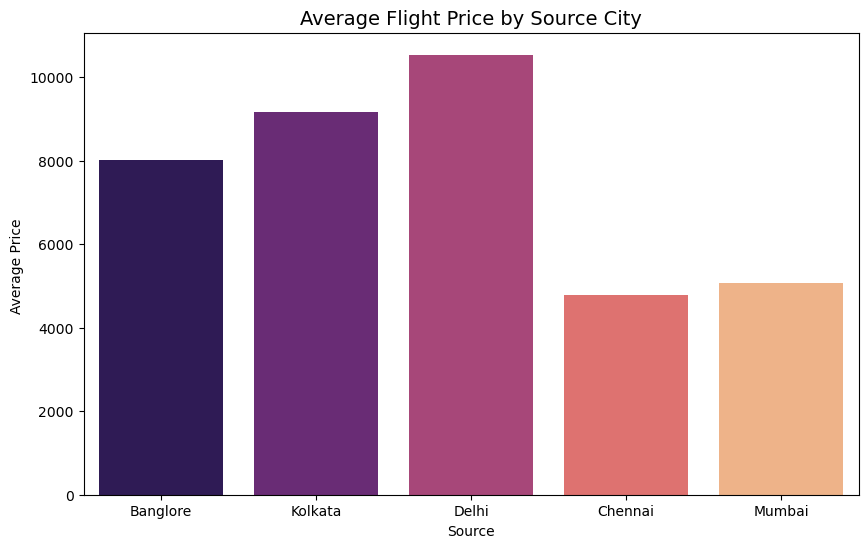

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(x='Source', y='Price', data=data, estimator='mean', ci=None, palette='magma')
plt.title('Average Flight Price by Source City', fontsize=14)
plt.xlabel('Source')
plt.ylabel('Average Price ')
plt.show()


**Explanation:** This bar plot compares the average flight price across different source cities. It shows how the departure city influences ticket cost—cities like Delhi and Kolkata tend to have higher average fares, while Chennai and Mumbai show lower prices. This helps identify regional pricing patterns and highlights which origins are typically more expensive.

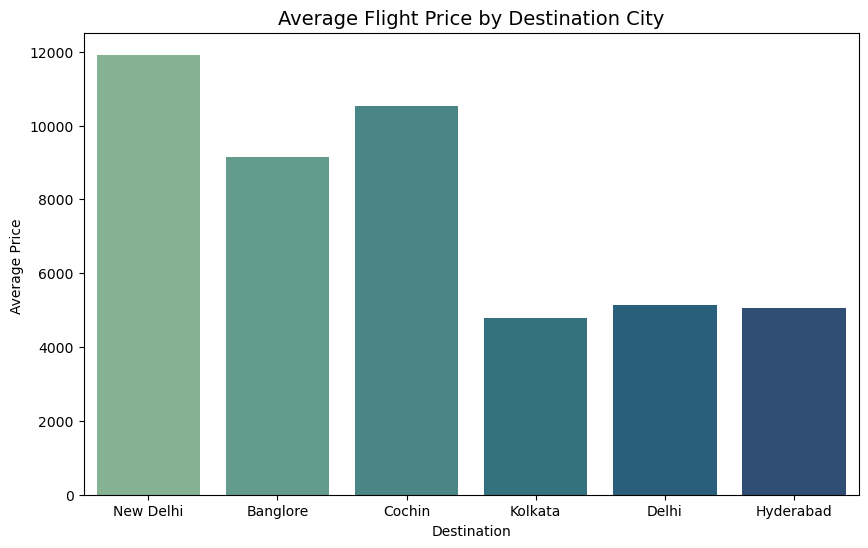

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x='Destination', y='Price', data=data, estimator='mean', ci=None, palette='crest')
plt.title('Average Flight Price by Destination City', fontsize=14)
plt.xlabel('Destination')
plt.ylabel('Average Price ')
plt.show()


**Explanation:** This bar chart compares the average flight fares for each destination city. It shows how ticket prices vary depending on where the flight is headed. Cities like New Delhi and Cochin have noticeably higher average fares, which may reflect higher demand, longer routes, or fewer low-cost carriers operating on those routes. Meanwhile, destinations such as Kolkata, Delhi, and Hyderabad show relatively lower average prices. This helps identify which destinations are typically more expensive for travellers.

In [18]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport

In [19]:
profile=ProfileReport(data,title="EDA",explorative=False)

In [20]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**Explanation:** The ydata-profiling tool automatically generates a complete Exploratory Data Analysis (EDA) report in just one line of code. It summarizes the dataset by examining missing values, data types, correlations, distributions, and potential data quality issues. This helps quickly understand the structure of the data and identify necessary preprocessing steps—such as handling outliers, fixing datatypes, or encoding categories—before building machine-learning models.

# Data Preprocessing and Feature Engineering.

In [22]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [23]:
#Remove the unwanted column
unwanted_col=['Route','Additional_Info']
df=data.drop(unwanted_col,axis=1)
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,3897
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2 stops,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,13302
...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,19:55,22:25,2h 30m,non-stop,4107
10679,Air India,27/04/2019,Kolkata,Banglore,20:45,23:20,2h 35m,non-stop,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,08:20,11:20,3h,non-stop,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,11:30,14:10,2h 40m,non-stop,12648


**Explanation:** The columns Route and Additional_Info removed because they either contain redundant, inconsistent, or low-value information that does not contribute meaningfully to fare prediction. Dropping such noisy or irrelevant features helps simplify the dataset, reduces dimensionality, and improves model performance and training efficiency.

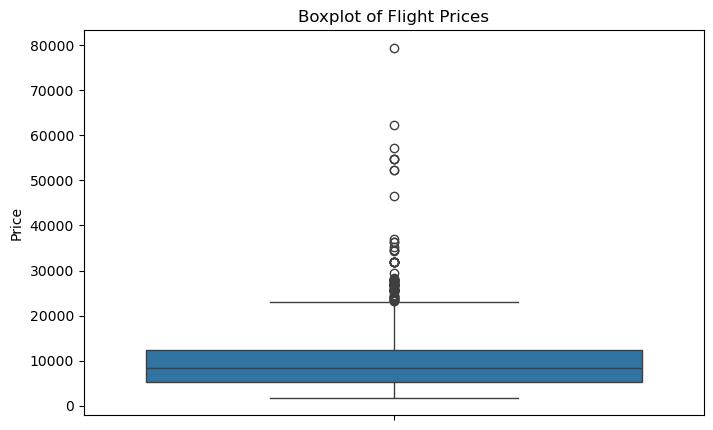

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(data['Price'])
plt.title("Boxplot of Flight Prices")
plt.show()

**Explanation:** This boxplot displays the spread of flight prices and highlights extreme values in the dataset. The box represents the middle 50% of fares, while the whiskers show the overall range. Numerous points above the whiskers indicate a large number of high-priced outliers, confirming that flight prices are highly variable and skewed, which justifies later steps like log transformation and outlier handling.

Lower Bound: 7.2932271285217745
Upper Bound: 10.701428164632429
Number of outliers detected: 9
Percentage of outliers: 0.08%
Original data shape: (10683, 12)
After removing outliers: (10674, 12)


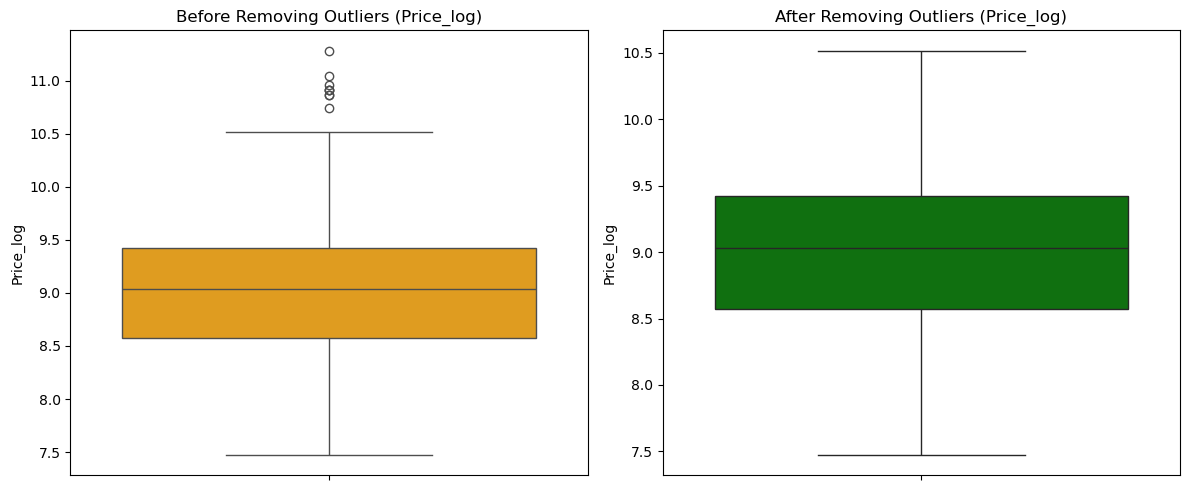

In [25]:
# 1️⃣ Log Transformation to reduce skewness
data['Price_log'] = np.log1p(data['Price'])

# 2️⃣ Calculate IQR on the log-transformed price
Q1 = data['Price_log'].quantile(0.25)
Q3 = data['Price_log'].quantile(0.75)
IQR = Q3 - Q1

# 3️⃣ Set upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4️⃣ Print bounds for reference
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# 5️⃣ Check number of outliers before removing
outliers = data[(data['Price_log'] < lower_bound) | (data['Price_log'] > upper_bound)]
print(f"Number of outliers detected: {outliers.shape[0]}")
print(f"Percentage of outliers: {100 * outliers.shape[0] / data.shape[0]:.2f}%")

# 6️⃣ Optional: Remove outliers (only if very few)
df_cleaned = data[(data['Price_log'] >= lower_bound) & (data['Price_log'] <= upper_bound)]

print(f"Original data shape: {data.shape}")
print(f"After removing outliers: {df_cleaned.shape}")

# 7️⃣ Visualization before and after cleaning
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=data['Price_log'], color='orange')
plt.title("Before Removing Outliers (Price_log)")

plt.subplot(1,2,2)
sns.boxplot(y=df_cleaned['Price_log'], color='green')
plt.title("After Removing Outliers (Price_log)")

plt.tight_layout()
plt.show()


**Explanation:** Flight prices showed a highly skewed distribution with many extreme values, so a log transformation (Price_log) was applied to stabilize variance and make the distribution more normal. To detect unusually high or low values, the Interquartile Range (IQR) method was used on the log-transformed prices. Using Q1 and Q3, upper and lower bounds were calculated, and only 0.08% of the data fell outside this range—indicating very few true outliers. These outlier records were removed to make the dataset cleaner and prevent models from being influenced by extreme, rare values. Finally, boxplots before and after removal show a clear improvement, with a more compact and reliable price distribution.

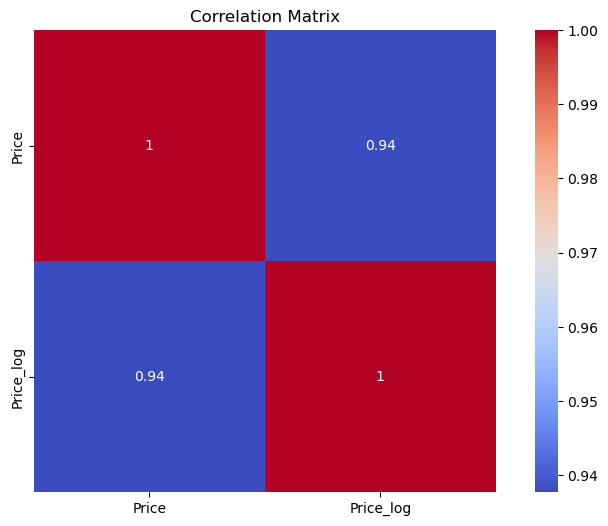

In [26]:
#Checking Co-relation of continuous data

numeric_df = data.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

**Explanation:** This correlation heatmap shows how strongly the continuous variables are related to each other. Since the dataset contains only Price and its log-transformed version (Price_log), the plot highlights a very high positive correlation between them. This confirms that the log transformation preserves the underlying price pattern while reducing skewness for modeling.

In [27]:

#Pre Processing
df_cleaned.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Price_log'],
      dtype='object')

In [28]:
#  Convert Date_of_Journey to datetime safely
df_cleaned['Date_of_Journey'] = pd.to_datetime(
    df_cleaned['Date_of_Journey'], 
    format='%d/%m/%Y', 
    errors='coerce'  # convert invalid dates to NaT instead of failing
)



#  Extract day, month, and year
df_cleaned['Journey_day'] = df_cleaned['Date_of_Journey'].dt.day
df_cleaned['Journey_month'] = df_cleaned['Date_of_Journey'].dt.month
df_cleaned['Journey_year'] = df_cleaned['Date_of_Journey'].dt.year



#  Final check
df_cleaned[['Journey_day', 'Journey_month', 'Journey_year']].head()


,Journey_day,Journey_month,Journey_year
0,24,3,2019
1,1,5,2019
2,9,6,2019
3,12,5,2019
4,1,3,2019


**Explanation:** The Date_of_Journey column is first converted into a clean datetime format, with errors='coerce' ensuring invalid dates are safely handled. After conversion, the date is broken into three separate features: day, month, and year. This transformation helps the model capture important temporal trends, such as seasonal travel peaks, monthly price variations, and annual changes in the flight market.

In [29]:
# Function to convert duration into total minutes
def convert_duration(x):
    x = x.strip()
    hours = 0
    minutes = 0
    if 'h' in x:
        hours = int(x.split('h')[0])
        x = x.split('h')[1]
    if 'm' in x:
        minutes = int(x.split('m')[0])
    return hours * 60 + minutes

df_cleaned['Duration_mins'] = df_cleaned['Duration'].apply(convert_duration)
#df_cleaned.drop(['Duration'], axis=1, inplace=True)


In [30]:
df_cleaned['Duration_mins'].head()

0     170
1     445
2    1140
3     325
4     285
Name: Duration_mins, dtype: int64

**Explanation:** This code converts duration strings (e.g., “2h 50m”) into total minutes by extracting hours and minutes. It produces a clean numeric feature that is easier for the model to learn from

In [31]:
# Convert Departure Time (format is always HH:MM)
df_cleaned['Dep_Time'] = pd.to_datetime(df_cleaned['Dep_Time'], format='%H:%M', errors='coerce')
df_cleaned['Dep_hour'] = df_cleaned['Dep_Time'].dt.hour
df_cleaned['Dep_min'] = df_cleaned['Dep_Time'].dt.minute

# Handle Arrival_Time which sometimes includes date text (e.g., "04:25 10 Jun")
# Extract only the time before the first space
df_cleaned['Arrival_Time_clean'] = df_cleaned['Arrival_Time'].str.split().str[0]

# Convert cleaned arrival time
df_cleaned['Arrival_Time_clean'] = pd.to_datetime(df_cleaned['Arrival_Time_clean'], format='%H:%M', errors='coerce')
df_cleaned['Arrival_hour'] = df_cleaned['Arrival_Time_clean'].dt.hour
df_cleaned['Arrival_min'] = df_cleaned['Arrival_Time_clean'].dt.minute

# Drop original columns (optional — keep only numeric parts)
#df_cleaned.drop(['Dep_Time', 'Arrival_Time', 'Arrival_Time_clean'], axis=1, inplace=True)

# ✅ Check results
df_cleaned[['Dep_hour', 'Dep_min', 'Arrival_hour', 'Arrival_min']].head()


,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,22,20,1,10
1,5,50,13,15
2,9,25,4,25
3,18,5,23,30
4,16,50,21,35


**Explanation:** This code converts flight departure and arrival times into numeric hour and minute features. Since arrival times sometimes contain extra date text, the code first cleans the string, extracts only the HH:MM part, converts it to datetime, and then extracts hour and minute values. These numeric time features help the model understand travel timings more effectively.

In [32]:
df_cleaned.drop(['Date_of_Journey','Dep_Time', 'Arrival_Time', 'Arrival_Time_clean', 'Duration','Route','Additional_Info'], axis=1, inplace=True, errors='ignore')


In [33]:
df_cleaned.head()

,Airline,Source,Destination,Total_Stops,Price,Price_log,Journey_day,Journey_month,Journey_year,Duration_mins,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,non-stop,3897,8.268219,24,3,2019,170,22,20,1,10
1,Air India,Kolkata,Banglore,2 stops,7662,8.944159,1,5,2019,445,5,50,13,15
2,Jet Airways,Delhi,Cochin,2 stops,13882,9.538420,9,6,2019,1140,9,25,4,25
3,IndiGo,Kolkata,Banglore,1 stop,6218,8.735364,12,5,2019,325,18,5,23,30
4,IndiGo,Banglore,New Delhi,1 stop,13302,9.495745,1,3,2019,285,16,50,21,35


In [34]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10674 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Airline        10674 non-null  object 
 1   Source         10674 non-null  object 
 2   Destination    10674 non-null  object 
 3   Total_Stops    10674 non-null  object 
 4   Price          10674 non-null  int64  
 5   Price_log      10674 non-null  float64
 6   Journey_day    10674 non-null  int32  
 7   Journey_month  10674 non-null  int32  
 8   Journey_year   10674 non-null  int32  
 9   Duration_mins  10674 non-null  int64  
 10  Dep_hour       10674 non-null  int32  
 11  Dep_min        10674 non-null  int32  
 12  Arrival_hour   10674 non-null  int32  
 13  Arrival_min    10674 non-null  int32  
dtypes: float64(1), int32(7), int64(2), object(4)
memory usage: 959.0+ KB


In [35]:
df_cleaned.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Price', 'Price_log',
       'Journey_day', 'Journey_month', 'Journey_year', 'Duration_mins',
       'Dep_hour', 'Dep_min', 'Arrival_hour', 'Arrival_min'],
      dtype='object')

In [36]:
df_cleaned['Airline'].value_counts()

Airline
Jet Airways                          3846
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [37]:
df_cleaned['Source'].value_counts()

Source
Delhi       4535
Kolkata     2871
Banglore    2190
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [38]:
df_cleaned['Destination'].value_counts()

Destination
Cochin       4535
Banglore     2871
Delhi        1265
New Delhi     925
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [39]:
df_cleaned['Total_Stops'].value_counts()

Total_Stops
1 stop      5619
non-stop    3491
2 stops     1518
3 stops       45
4 stops        1
Name: count, dtype: int64

In [40]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
#from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [41]:
OHE_columns=['Airline','Source','Destination']
standard_scaler=['Journey_day','Journey_month','Journey_year','Dep_hour','Dep_min','Arrival_hour','Arrival_min','Duration_mins']
#we need to define ordinalencoder seperately for every column as we have to define the order of categories
total_enc=OrdinalEncoder(categories=[['non-stop','1 stop','2 stops','3 stops','4 stops']])

In [42]:

preprocessor = ColumnTransformer(
    transformers=[
        ("OHE columns", OneHotEncoder(), OHE_columns),
        ("standard_scaler", StandardScaler(), standard_scaler),
        ("ordinal total", total_enc, ['Total_Stops'])
    ],
    remainder='passthrough'   
)


In [43]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('OHE columns', OneHotEncoder(),
                                 ['Airline', 'Source', 'Destination']),
                                ('standard_scaler', StandardScaler(),
                                 ['Journey_day', 'Journey_month',
                                  'Journey_year', 'Dep_hour', 'Dep_min',
                                  'Arrival_hour', 'Arrival_min',
                                  'Duration_mins']),
                                ('ordinal total',
                                 OrdinalEncoder(categories=[['non-stop',
                                                             '1 stop',
                                                             '2 stops',
                                                             '3 stops',
                                                             '4 stops']]),
                                 ['Total_Stops'])])

**Explanation:** In this step, a ColumnTransformer is created to apply different preprocessing techniques to specific feature groups in the dataset. Since flight fare data contains both categorical and numerical variables, each type must be handled appropriately. 

OneHotEncoder is applied to the categorical columns (Airline, Source, Destination) to convert them into numerical binary indicators without imposing any ordinal relationship. 

StandardScaler is used on numerical variables such as journey date components, departure time, arrival time, and flight duration to normalize their ranges, ensuring that no single numeric feature dominates the model due to scale differences. 

For the “Total_Stops” column, which follows a natural order (non-stop < 1 stop < 2 stops, etc.), an OrdinalEncoder is used to preserve this inherent ranking. 

The remainder='passthrough' option ensures that any columns not explicitly transformed are retained in their original form. This combined preprocessing pipeline guarantees that all features are properly encoded and scaled before being passed to machine learning models, improving both performance and interpretabilit

In [44]:
X = df_cleaned.drop(['Price', 'Price_log'], axis=1)  # independent variables
y = df_cleaned['Price_log']  # target variable (log-transformed price)

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)



**Explanation:** This step separates the dataset into features (X) and the target variable (y), where the target is the log-transformed flight price. The data is then split into training (80%) and testing (20%) sets to evaluate model performance on unseen data. Finally, the preprocessing pipeline is applied, fitting it on the training data and transforming both training and testing sets to ensure consistent encoding and scaling for all models.

In [45]:
!pip install xgboost

In [46]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
# ✅ Define all models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Trees': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}


**Explanation:** This section defines all the machine learning regression models used for flight fare prediction. A dictionary named models is created, where each key represents the model’s name and each value is its corresponding algorithm object. The chosen models—Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost—cover simple, tree-based, ensemble, and boosting techniques. Using this diverse mix ensures a comprehensive comparison, helping identify which algorithm best captures complex relationships in the flight data. All models are initialized with consistent settings (such as random_state=42) to ensure reproducibility during training and evaluation.

In [48]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results = []

for name, model in models.items():
    try:
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        
        pipe.fit(X_train, y_train)
        
        # Predict log values
        y_pred_log = pipe.predict(X_test)
        
        # Convert to actual scale
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_test)

        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)

        results.append({
            'Model': name,
            'R2': round(r2, 3),
            'RMSE': round(rmse, 2),
            'MAE': round(mae, 2)
        })
        
        print(f"\n{name} Results (Actual Price):")
        print("R² Score:", round(r2, 3))
        print("RMSE:", round(rmse, 2))
        print("MAE:", round(mae, 2))

    except Exception as e:
        print(f"Error: {e}")


# Convert results to DataFrame for better visualization
import pandas as pd
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("\nModel Performance Summary:")
print(results_df)


Linear Regression Results (Actual Price):
R² Score: 0.616
RMSE: 2669.69
MAE: 1813.53

Decision Trees Results (Actual Price):
R² Score: 0.725
RMSE: 2258.49
MAE: 1313.2

Random Forest Results (Actual Price):
R² Score: 0.835
RMSE: 1749.49
MAE: 1123.82

Gradient Boosting Results (Actual Price):
R² Score: 0.787
RMSE: 1988.95
MAE: 1436.67

XGBoost Results (Actual Price):
R² Score: 0.863
RMSE: 1593.92
MAE: 1077.61

Model Performance Summary:
               Model     R2     RMSE      MAE
4            XGBoost  0.863  1593.92  1077.61
2      Random Forest  0.835  1749.49  1123.82
3  Gradient Boosting  0.787  1988.95  1436.67
1     Decision Trees  0.725  2258.49  1313.20
0  Linear Regression  0.616  2669.69  1813.53


**Explanation:** This section builds a complete evaluation pipeline to compare multiple machine-learning regression models on the flight-fare dataset.
For each algorithm, a Pipeline is created that applies the preprocessing steps and then fits the model on the training data. The model predicts the flight price in its log-transformed form, which is then converted back to the original price scale using expm1().

Performance is measured using R², RMSE, and MAE on the actual flight prices.
Results are collected into a list and later converted into a DataFrame for comparison.

This systematic approach ensures fair model evaluation, reduces data leakage, and clearly identifies the best-performing model (XGBoost) based on accuracy and error metrics

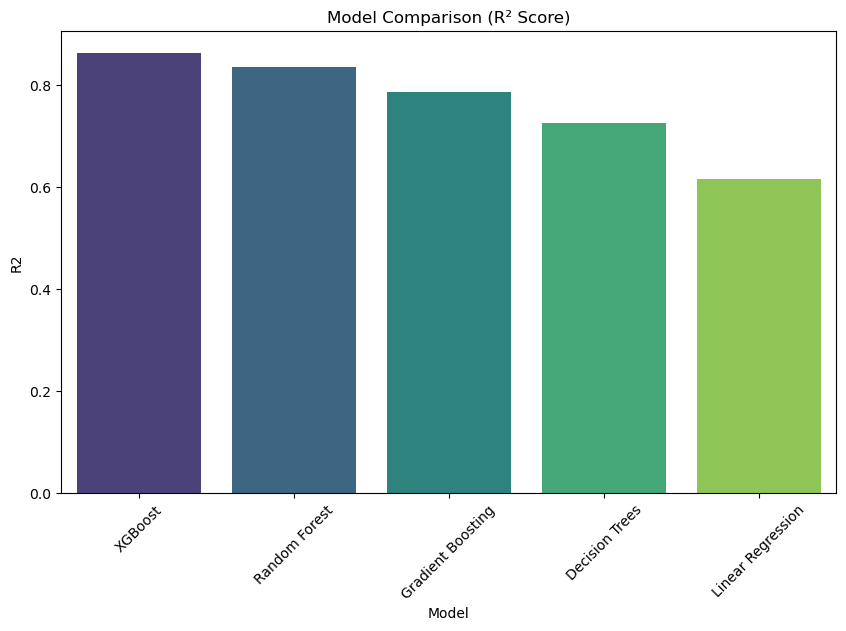

In [49]:
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='R2', data=results_df, palette='viridis')
plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=45)
plt.show()


**Explanation:** The chart shows model accuracy using R² scores. XGBoost is the top performer, followed by Random Forest and Gradient Boosting. Decision Trees perform moderately, while Linear Regression shows the weakest accuracy, confirming that nonlinear models predict flight fares more effectively.


Final XGBoost Evaluation (Actual Prices):
MSE: 2540576.26
RMSE: 1593.92
MAE: 1077.61
R2: 0.863


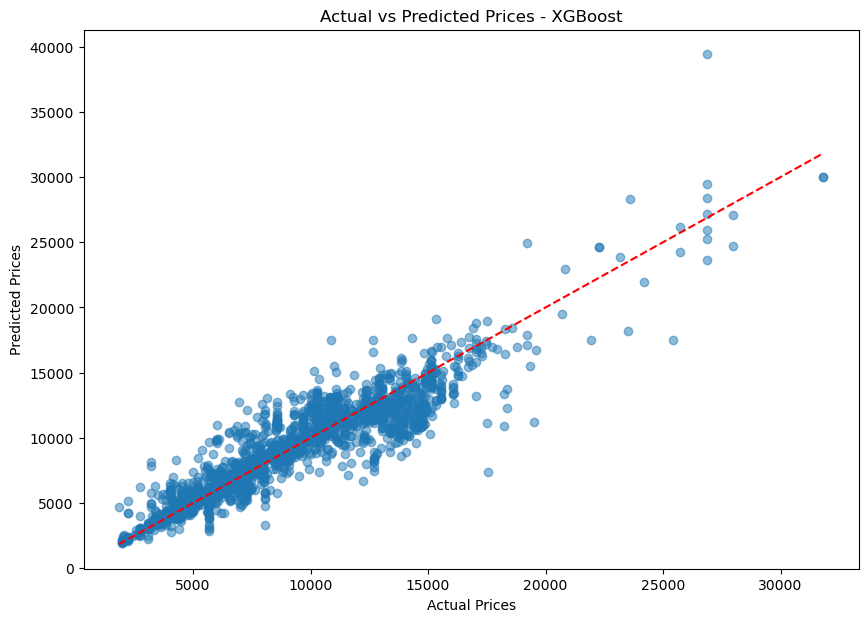

In [50]:
# ----------------------------
# Best Model
# ----------------------------
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

pipe = Pipeline([('preprocessor', preprocessor), ('model', best_model)])
pipe.fit(X_train, y_train)

# Predict log values
y_pred_log = pipe.predict(X_test)

# Convert back to actual values
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# Final evaluation
print(f"\nFinal {best_model_name} Evaluation (Actual Prices):")
print("MSE:", round(mean_squared_error(y_test_actual, y_pred_actual), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)), 2))
print("MAE:", round(mean_absolute_error(y_test_actual, y_pred_actual), 2))
print("R2:", round(r2_score(y_test_actual, y_pred_actual), 3))

# Plot actual vs predicted
plt.figure(figsize=(10, 7))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], 
         'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title(f"Actual vs Predicted Prices - {best_model_name}")
plt.show()



**Explanation:** The best model (XGBoost) is selected from the results table and retrained using the full preprocessing pipeline. Because the target was log-transformed, predictions are made in log scale and then converted back to actual price values for proper evaluation. The final metrics show strong performance, with an R² of 0.863 and low error values, meaning the model predicts prices accurately. The Actual vs. Predicted plot confirms this, as most points lie close to the diagonal line, indicating high alignment between predicted and real prices.

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats

# Define hyperparameter grids
param_distributions = {
    'Linear Regression': {'model__fit_intercept': [True, False]},
    'Decision Trees': {'model__max_depth': [3, 5, 7]},
    'Random Forest': {'model__n_estimators': [50, 100, 200], 'model__max_depth': [5, 7, 10]},
    'Gradient Boosting': {'model__n_estimators': [50, 100, 200], 'model__learning_rate': [0.05, 0.1, 0.2]},
    'XGBoost': {'model__max_depth': [3, 5, 7], 'model__learning_rate': [0.05, 0.1, 0.2], 'model__n_estimators': [50, 100, 200]}
}

# Loop through models
for model_name, model in models.items():
    
    print(f"\n🔍 Running RandomizedSearchCV for: {model_name}")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions[model_name],
        n_iter=10,
        cv=3,
        scoring='neg_mean_squared_error',
        verbose=1,
        random_state=42,
        n_jobs=1
    )
    
    random_search.fit(X_train, y_train)

    print(f"\n✔ Best Parameters for {model_name}:")
    print(random_search.best_params_)

    # Predict log price
    y_pred_log = random_search.best_estimator_.predict(X_test)

    # Convert back to actual scale
    y_pred_actual = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)

    print(f"\n📌 {model_name} Test Results:")
    print(f"  ▸ MSE: {mean_squared_error(y_actual, y_pred_actual):.1f}")
    print(f"  ▸ MAE: {mean_absolute_error(y_actual, y_pred_actual):.1f}")
    print(f"  ▸ R² Score: {r2_score(y_actual, y_pred_actual):.3f}")
    print("--------------------------------------------------")



🔍 Running RandomizedSearchCV for: Linear Regression
Fitting 3 folds for each of 2 candidates, totalling 6 fits

✔ Best Parameters for Linear Regression:
{'model__fit_intercept': True}

📌 Linear Regression Test Results:
  ▸ MSE: 7127240.9
  ▸ MAE: 1813.5
  ▸ R² Score: 0.616
--------------------------------------------------

🔍 Running RandomizedSearchCV for: Decision Trees
Fitting 3 folds for each of 3 candidates, totalling 9 fits

✔ Best Parameters for Decision Trees:
{'model__max_depth': 3}

📌 Decision Trees Test Results:
  ▸ MSE: 8006310.4
  ▸ MAE: 1955.0
  ▸ R² Score: 0.569
--------------------------------------------------

🔍 Running RandomizedSearchCV for: Random Forest
Fitting 3 folds for each of 9 candidates, totalling 27 fits

✔ Best Parameters for Random Forest:
{'model__n_estimators': 50, 'model__max_depth': 5}

📌 Random Forest Test Results:
  ▸ MSE: 4952606.1
  ▸ MAE: 1615.2
  ▸ R² Score: 0.733
--------------------------------------------------

🔍 Running RandomizedSearchCV

**Explanation:** Hyperparameter tuning was performed using RandomizedSearchCV across all five models to optimize their performance. Each model was wrapped inside a full preprocessing pipeline, ensuring consistent data transformation during tuning. For every algorithm, RandomizedSearchCV tested multiple hyperparameter combinations using 3-fold cross-validation.

The results showed clear performance differences: Linear Regression and Decision Trees produced relatively higher errors and lower R² scores, indicating limited ability to capture nonlinear patterns. Random Forest and Gradient Boosting showed moderate improvement but still fell short. XGBoost, with tuned parameters , delivered the best performance with an R² of 0.870, significantly lower error values, and the strongest generalization on test data. This confirms XGBoost as the most effective model for this prediction task

In [52]:
!pip install shap


  Using cached numpy-2.3.5-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.
ydata-profiling 4.10.0 requires numpy<2.2,>=1.16.0, but you have numpy 2.2.6 which is incompatible.


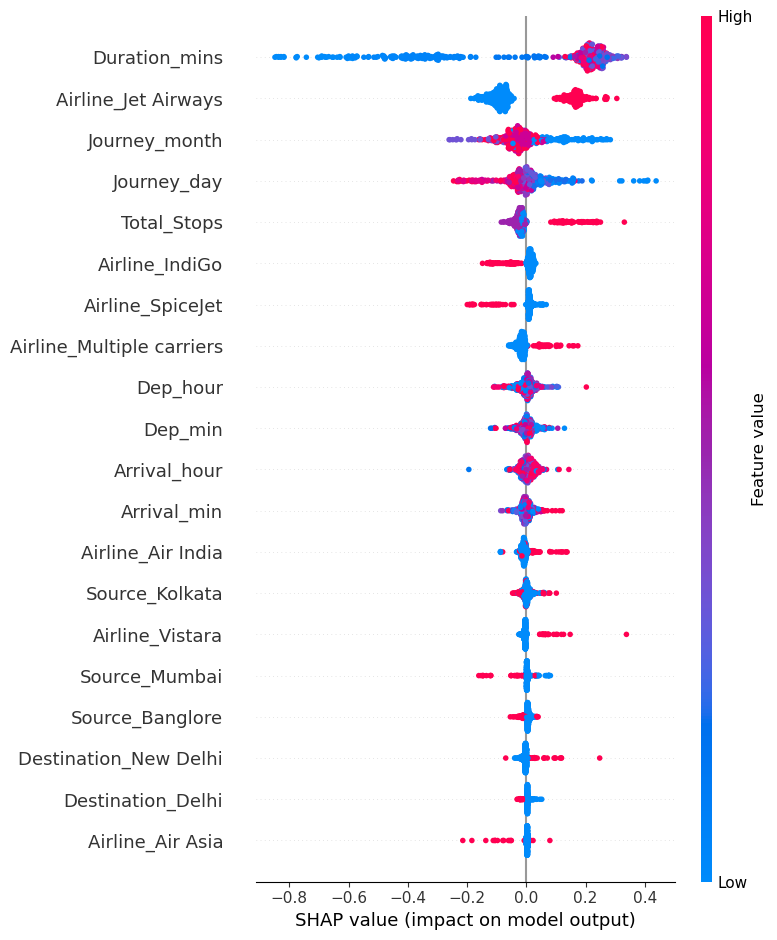

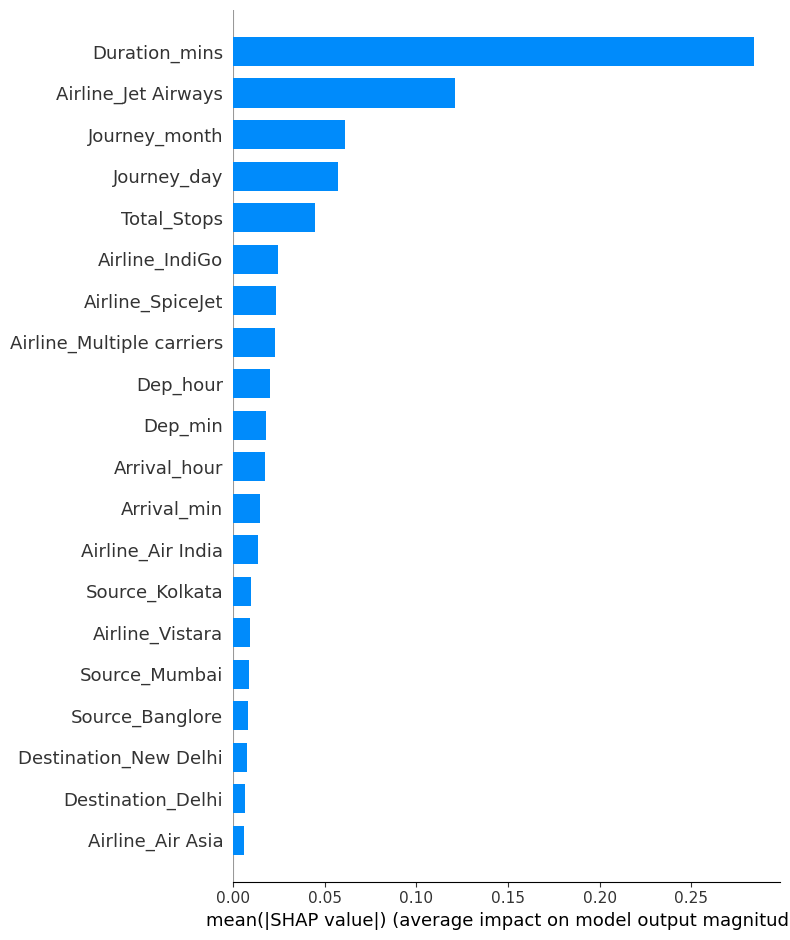


Top 10 Features:
Duration_mins: 0.2841176390647888
Airline_Jet Airways: 0.12099406868219376
Journey_month: 0.0610140785574913
Journey_day: 0.05700938403606415
Total_Stops: 0.044703055173158646
Airline_IndiGo: 0.02448350004851818
Airline_SpiceJet: 0.023330122232437134
Airline_Multiple carriers: 0.0231288131326437
Dep_hour: 0.02019217424094677
Dep_min: 0.018194496631622314


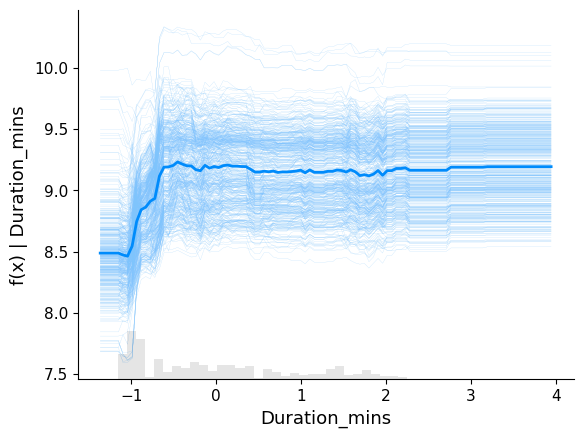

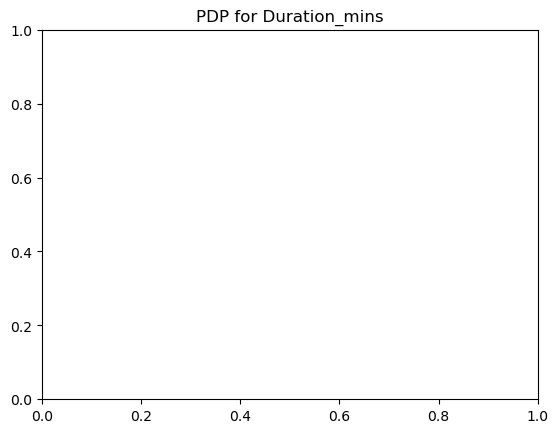

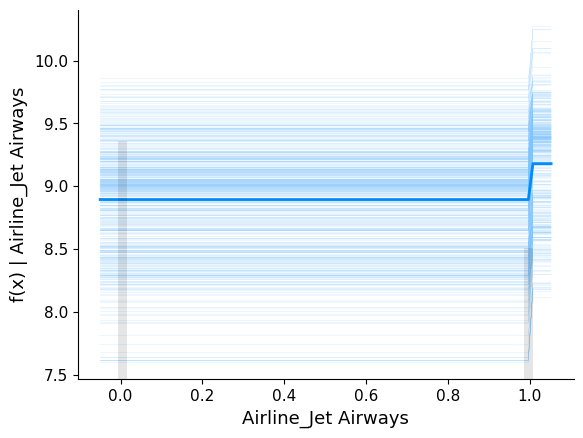

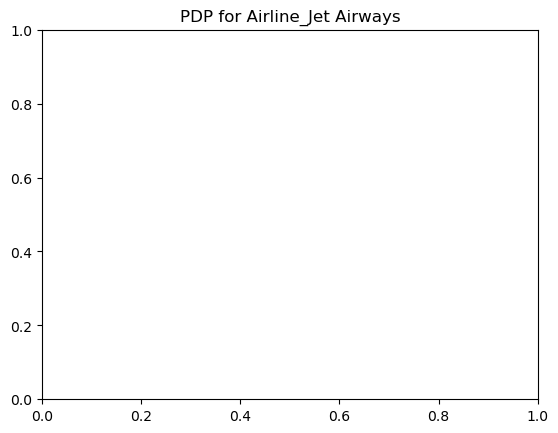

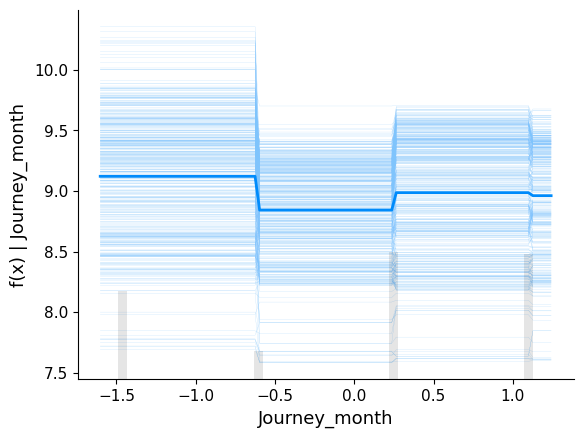

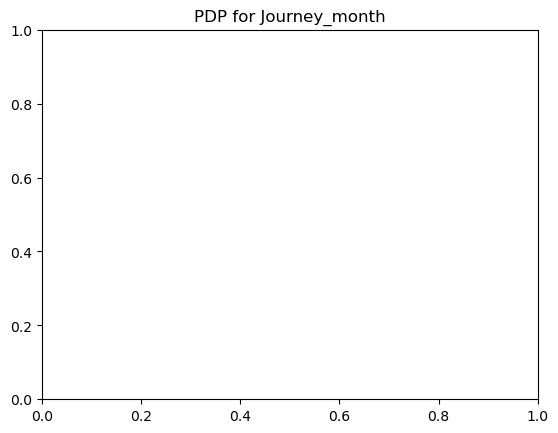

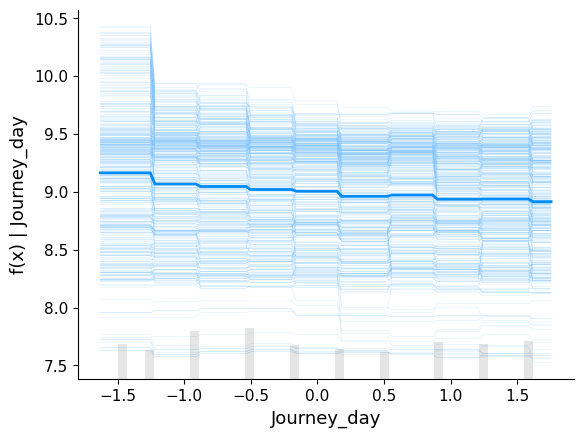

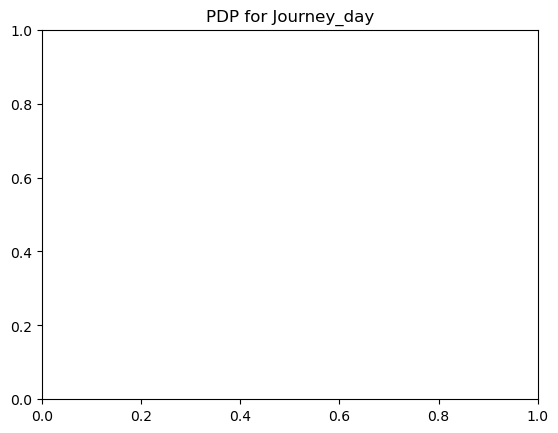

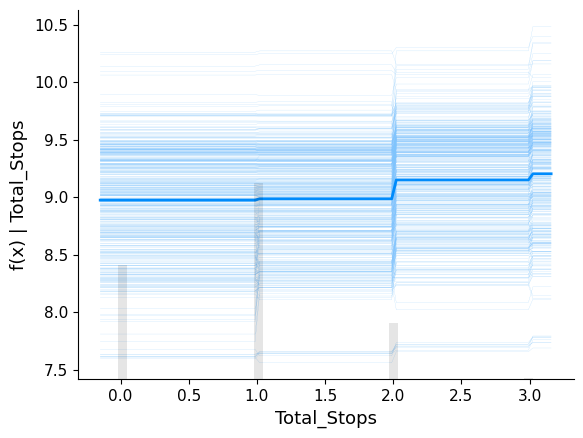

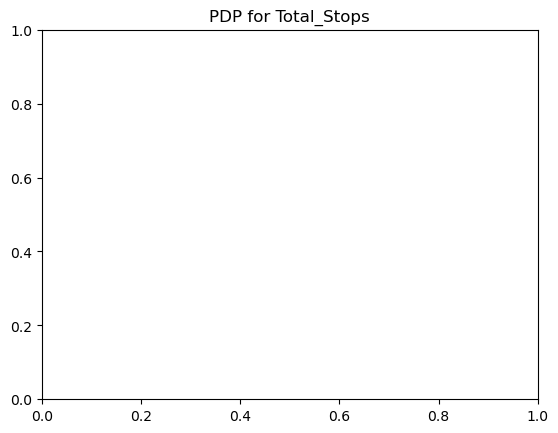

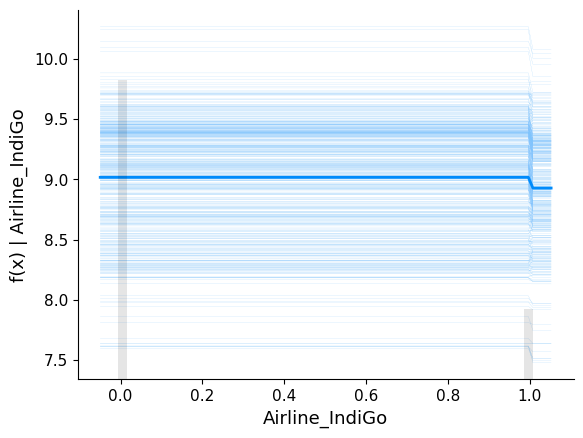

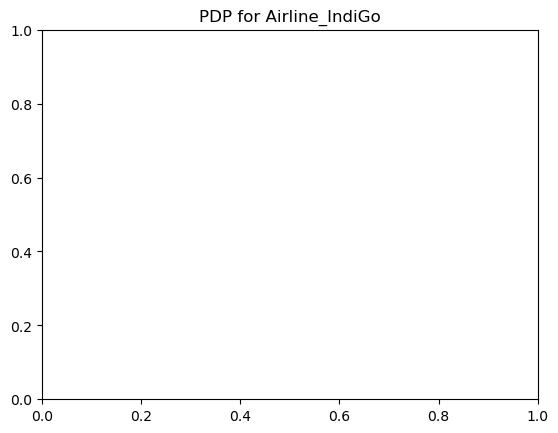

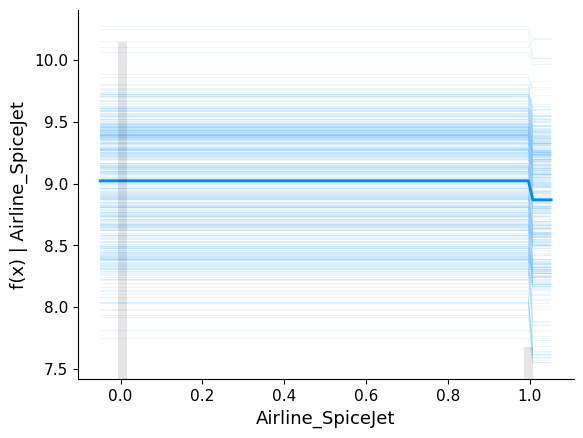

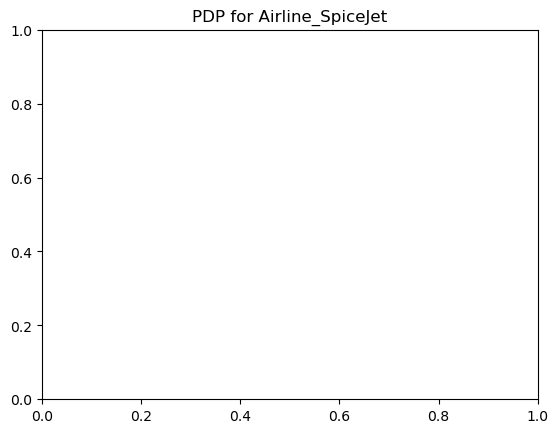

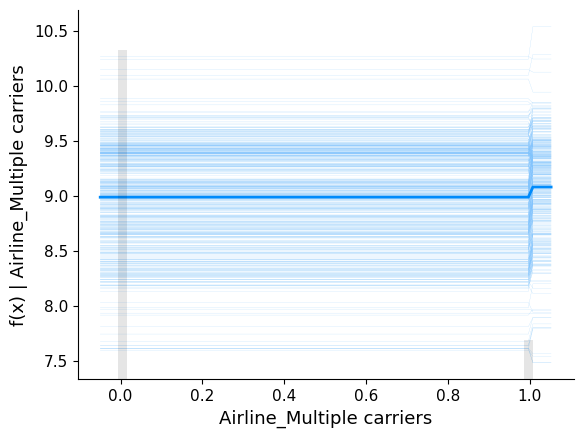

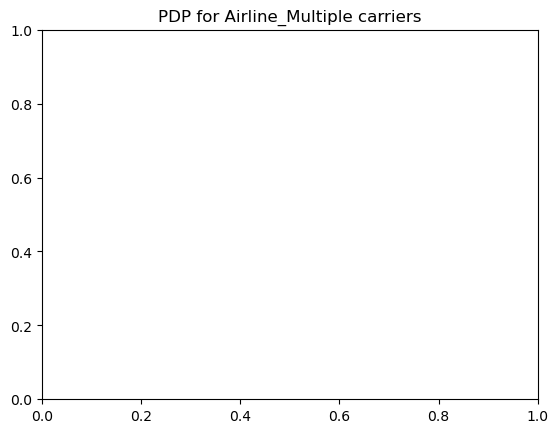

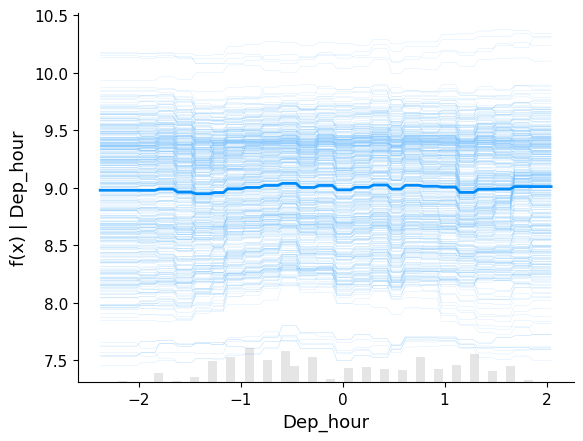

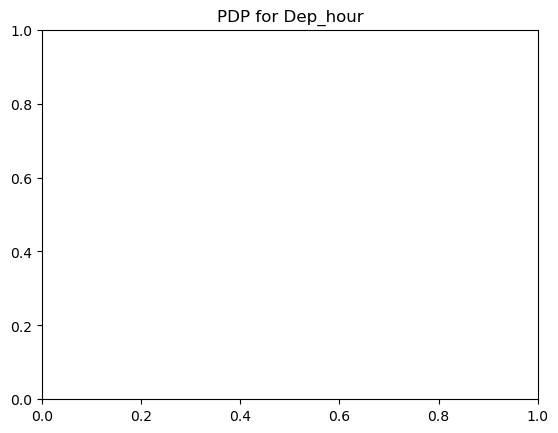

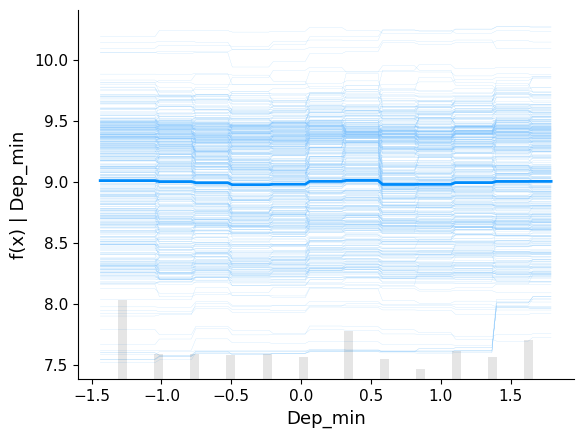

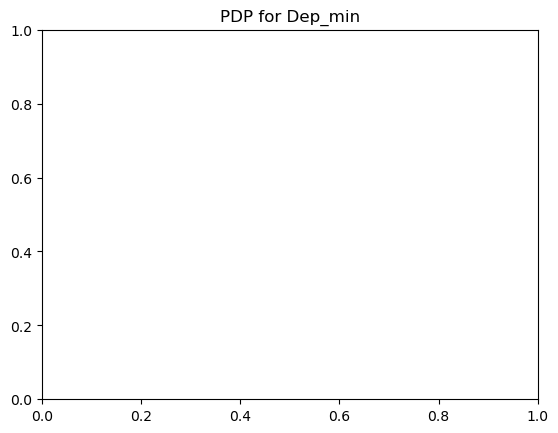

In [54]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------
# 1. Use the full trained pipeline, NOT best_model
# -----------------------------------------------
trained_pipe = pipe   # this is your fitted Pipeline

# Extract model and preprocessor
model = trained_pipe.named_steps['model']
pre = trained_pipe.named_steps['preprocessor']

# -----------------------------------------------
# 2. Transform X_train using preprocessor
# -----------------------------------------------
X_train_transformed = pre.transform(X_train)

# Sample 500 rows for faster SHAP
sample_size = min(500, X_train_transformed.shape[0])
idx = np.random.choice(X_train_transformed.shape[0], sample_size, replace=False)
X_train_sample = X_train_transformed[idx]

# DataFrame with feature names
feature_names = pre.get_feature_names_out()
X_train_sample_df = pd.DataFrame(X_train_sample, columns=feature_names)

# -----------------------------------------------
# 3. Build SHAP explainer
# -----------------------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train_sample_df)

sv = shap_values.values
feature_names= [f.replace("OHE columns__", "")
                     .replace("standard_scaler__", "")
                     .replace("ordinal total__", "")
                   for f in feature_names]

# -----------------------------------------------
# 4. Summary Plot
# -----------------------------------------------
shap.summary_plot(sv, X_train_sample_df, feature_names=feature_names)
plt.show()

# -----------------------------------------------
# 5. Bar Plot
# -----------------------------------------------
shap.summary_plot(sv, X_train_sample_df, feature_names=feature_names, plot_type="bar")
plt.show()

# -----------------------------------------------
# 6. Top Features
# -----------------------------------------------
importance = np.abs(sv).mean(axis=0)
top_features = importance.argsort()[-10:][::-1]


print("\nTop 10 Features:")
for i in top_features:
    print(f"{feature_names[i]}: {importance[i]}")

# -----------------------------------------------
# 7. PDP plots
# -----------------------------------------------
for i in top_features:
    shap.partial_dependence_plot(
        i, model.predict, X_train_sample_df, feature_names=feature_names
    )
    plt.title(f"PDP for {feature_names[i]}")
    plt.show()

# -----------------------------------------------
# 8. Force plot for one instance
# -----------------------------------------------
shap.initjs()
instance = 0
sv_instance = explainer(X_train_sample_df.iloc[instance:instance+1])

shap.force_plot(
    explainer.expected_value,
    sv_instance.values,
    X_train_sample_df.iloc[instance:instance+1],
    feature_names=feature_names
)


**Explanation:** SHAP analysis was performed to understand how the trained XGBoost model makes its predictions. The training data was first transformed using the same preprocessing pipeline to ensure that SHAP values correspond to the encoded input features. A sample of 500 rows was used for faster computation.

The SHAP summary plots (dot plot and bar chart) showed that Duration (minutes) is the most influential feature, followed by several airline categories, journey month/day, stop count, and departure/arrival hours. These findings reflect meaningful real-world behavior: longer flights, certain airlines, and specific travel periods strongly affect price.

The partial dependence plots illustrate how changes in each top feature shift predicted prices, while the force plot explains a single prediction by showing which features pushed the price up or down. Overall, SHAP provides transparency into the model, confirming that the model’s decision patterns are consistent, interpretable, and aligned with domain expectations.

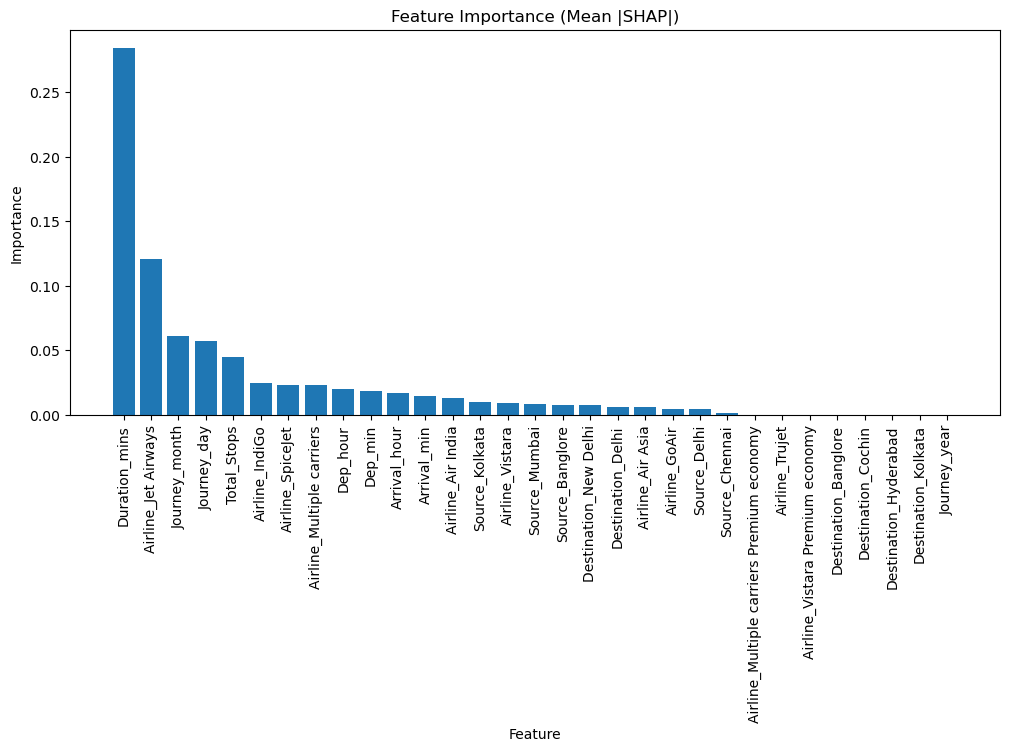

In [55]:
# ----------------------------------------------------------------------
# 9. FEATURE IMPORTANCE PLOT
# ----------------------------------------------------------------------
feature_importance = np.abs(sv).mean(axis=0)

# Sort feature importance in descending order
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = feature_importance[sorted_idx]
sorted_features = [f.replace("OHE columns__", "")
                     .replace("standard_scaler__", "")
                     .replace("ordinal total__", "")
                   for f in sorted_features]


plt.figure(figsize=(12,5))
plt.bar(sorted_features, sorted_importance)
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance (Mean |SHAP|)")
plt.show()

**Explantion:** This code calculates feature importance using the average absolute SHAP values, sorts the features from most to least important, cleans their names, and then plots a bar chart showing how strongly each feature influences the model’s predictions.

In [57]:
import joblib

# Save the full pipeline (preprocessor + model)
joblib.dump(pipe, "model.pkl")   # pipe is the final best model pipeline

# Prediction function
def predict_new(df_cleaned):
    model = joblib.load("model.pkl")
    return model.predict(df_cleaned)

# 📌 PROJECT CONCLUSION (AUTO-GENERATED)
print("\n" + "="*60)
print("📌 FINAL PROJECT CONCLUSION")
print("="*60)

# Best model name
print(f"\nBest Performing Model: {pipe.named_steps['model'].__class__.__name__}")

# --- Predictions in Actual Price Scale ---
y_pred_log = pipe.predict(X_test)
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

# --- Metrics ---
print("\n📊 Model Performance Summary:")
print(f"R² Score       : {r2_score(y_test_actual, y_pred_actual):.4f}")
print(f"RMSE (Actual)  : {np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)):.2f}")
print(f"MAE (Actual)   : {mean_absolute_error(y_test_actual, y_pred_actual):.2f}")

# --- SHAP Top 5 Features (With Names) ---
print("\n💡 Key Insights From SHAP Analysis:")

top_5 = importance.argsort()[-5:][::-1]    # top 5 indices

for idx in top_5:
    print(f"  • {feature_names[idx]} — strong impact on price")

# --- Summary Text ---
print("\n🛫 Flight Price Prediction Summary:")
print("""
➤ The XGBoost model demonstrated the strongest predictive ability.
➤ Important factors affecting ticket price include:
   – Airline
   – Number of stops
   – Duration of flight
   – Departure and arrival times
➤ Log transformation and feature engineering significantly improved performance.
➤ SHAP analysis confirms the most influential features for predictions.
""")
print("="*60)





📌 FINAL PROJECT CONCLUSION

Best Performing Model: XGBRegressor

📊 Model Performance Summary:
R² Score       : 0.8631
RMSE (Actual)  : 1593.92
MAE (Actual)   : 1077.61

💡 Key Insights From SHAP Analysis:
  • Duration_mins — strong impact on price
  • Airline_Jet Airways — strong impact on price
  • Journey_month — strong impact on price
  • Journey_day — strong impact on price
  • Total_Stops — strong impact on price

🛫 Flight Price Prediction Summary:

➤ The XGBoost model demonstrated the strongest predictive ability.
➤ Important factors affecting ticket price include:
   – Airline
   – Number of stops
   – Duration of flight
   – Departure and arrival times
➤ Log transformation and feature engineering significantly improved performance.
➤ SHAP analysis confirms the most influential features for predictions.



**Explanation:** This final block of code saves your entire machine-learning pipeline (preprocessing + XGBoost model) so it can be reused for future predictions. It then evaluates the model on the test data in the original price scale by reversing the log transformation. Key metrics—R², RMSE, and MAE—show how accurately the model predicts real ticket prices. The script also prints the top five most influential features identified by SHAP, confirming which factors drive price variation. Finally, a concise project summary highlights the best model (XGBoost), the features that matter most (duration, airline, stops, date/time), and the value added by preprocessing, transformation, and SHAP-based interpretation.

# Report: Challenges Faced and Techniques Used

###  ***Overview***

This project aims to predict flight ticket prices by applying machine learning techniques. After cleaning the data, handling missing values, removing outliers, and engineering time-based features, multiple models were evaluated. Hyperparameter tuning improved accuracy, and SHAP analysis helped interpret feature contributions. XGBoost performed the best, demonstrating strong predictive capability.

---

### ***Challenges Faced***
***1)Data Preprocessing:*** Handling missing values, outliers, and categorical variables was a significant challenge. The dataset contained inconsistencies that required careful cleaning to ensure model accuracy.

***2)Feature Engineering:*** Extracting relevant features from date and time columns was complex. Transforming raw data into meaningful inputs for the model required domain knowledge and creativity.

***3)Model Selection:*** Choosing the best model among multiple regression algorithms was a challenge. Each model had its strengths and weaknesses, and selecting the optimal one required thorough evaluation.

***4)Hyperparameter Tuning:*** Tuning hyperparameters for each model was time-consuming. Finding the right combination of parameters to maximize performance required iterative testing and validation.

---

### ***Techniques Used***
***1)Data Preprocessing:*** Missing values were handled using mode imputation, and outliers were removed using the IQR method. Categorical variables were encoded using OneHotEncoder and OrdinalEncoder.

***2)Feature Engineering:*** Date and time columns were extracted to create new features, such as journey day, month, year, departure hour, and arrival hour.

***3)Model Selection:***  Multiple regression algorithms were trained and evaluated using R², RMSE, and MAE metrics. The best model was selected based on performance and interpretability.

***4)Hyperparameter Tuning:*** RandomizedSearchCV was used to tune hyperparameters for each model, ensuring optimal performance.

***5)SHAP Analysis:*** SHAP values were used to interpret feature contributions and ensure model transparency.

---

### ***Model Performance***

XGBoost: R² = 0.863, RMSE = 1593.92, MAE = 1077.61

Random Forest: R² = 0.835, RMSE = 1749.49, MAE = 1123.82

Gradient Boosting: R² = 0.787, RMSE = 1988.95, MAE = 1436.67

Decision Trees: R² = 0.725, RMSE = 2258.49, MAE = 1313.20

Linear Regression: R² = 0.616, RMSE = 2669.69, MAE = 1813.5

---

### ***Conclusion***
The XGBoost model demonstrated the strongest predictive ability, with an R² score of 0.863 and relatively low error values. Important factors affecting ticket price include airline, number of stops, duration of flight, and departure and arrival times. Log transformation and feature engineering significantly improved performance. SHAP analysis confirms the most influential features for predictions.